SOFTMAX on USPS dataset

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [15]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [16]:
usps = fetch_openml('usps', version=1)

X = usps.data
y = usps.target.astype(int)
y = y - 1

print(X.shape)   
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# convert everything to numpy arrays
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

# one-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

c:\Python310\lib\site-packages\sklearn\datasets\_openml.py:1035: UserWarning: Version 1 of dataset USPS is inactive, meaning that issues have been found in the dataset. Try using a newer version from this URL: https://openml.org/data/v1/download/18805612/USPS.arff
  warn(


(9298, 256)
(9298,)
Training data shape: (7438, 256)
Test data shape: (1860, 256)


In [17]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True)) 
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    n_samples = y_pred.shape[0]
    log_likelihood = -np.log(y_pred[range(n_samples), y_true.argmax(axis=1)])
    loss = np.sum(log_likelihood) / n_samples
    return loss

def softmax_gradient(y_pred, y_true):
    return y_pred - y_true

In [18]:
input_size = 256  # 16x16 pixels
output_size = 10  
lr = 0.01
epochs = 300

W = np.random.randn(input_size, output_size) * 0.01
b = np.zeros((1, output_size))

In [19]:
# training loop
for epoch in range(epochs):
    # forward pass
    z = np.dot(X_train, W) + b
    y_pred = softmax(z)
    
    loss = cross_entropy_loss(y_pred, y_train_onehot)
    
    # backward pass
    dz = softmax_gradient(y_pred, y_train_onehot)
    dW = np.dot(X_train.T, dz) / X_train.shape[0]
    db = np.sum(dz, axis=0, keepdims=True) / X_train.shape[0]
    
    # update parameters
    W -= lr * dW
    b -= lr * db
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

Epoch 10/300, Loss: 2.0484
Epoch 20/300, Loss: 1.8368
Epoch 30/300, Loss: 1.6727
Epoch 40/300, Loss: 1.5401
Epoch 50/300, Loss: 1.4299
Epoch 60/300, Loss: 1.3364
Epoch 70/300, Loss: 1.2560
Epoch 80/300, Loss: 1.1860
Epoch 90/300, Loss: 1.1247
Epoch 100/300, Loss: 1.0705
Epoch 110/300, Loss: 1.0224
Epoch 120/300, Loss: 0.9794
Epoch 130/300, Loss: 0.9408
Epoch 140/300, Loss: 0.9059
Epoch 150/300, Loss: 0.8744
Epoch 160/300, Loss: 0.8457
Epoch 170/300, Loss: 0.8195
Epoch 180/300, Loss: 0.7954
Epoch 190/300, Loss: 0.7733
Epoch 200/300, Loss: 0.7530
Epoch 210/300, Loss: 0.7341
Epoch 220/300, Loss: 0.7166
Epoch 230/300, Loss: 0.7003
Epoch 240/300, Loss: 0.6852
Epoch 250/300, Loss: 0.6710
Epoch 260/300, Loss: 0.6577
Epoch 270/300, Loss: 0.6452
Epoch 280/300, Loss: 0.6335
Epoch 290/300, Loss: 0.6224
Epoch 300/300, Loss: 0.6120


Test Accuracy: 88.76%


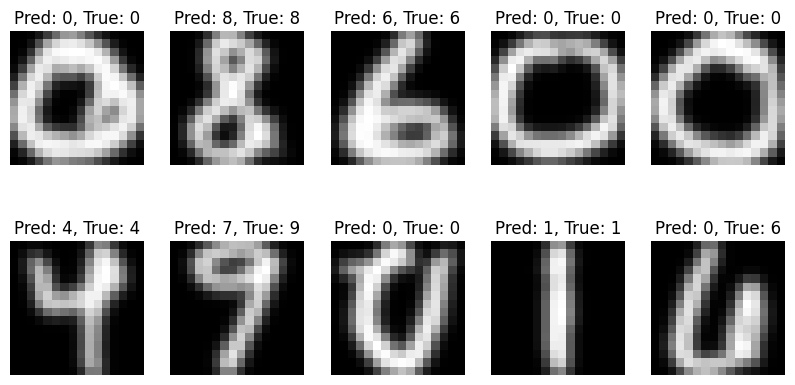

In [23]:
z_test = np.dot(X_test, W) + b
y_pred_test = softmax(z_test)
predictions = np.argmax(y_pred_test, axis=1)
true_labels = np.argmax(y_test_onehot, axis=1)

accuracy = np.mean(predictions == true_labels)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# visualization
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(16, 16), cmap='gray')
    ax.set_title(f"Pred: {predictions[i]}, True: {true_labels[i]}")
    ax.axis('off')
plt.show()

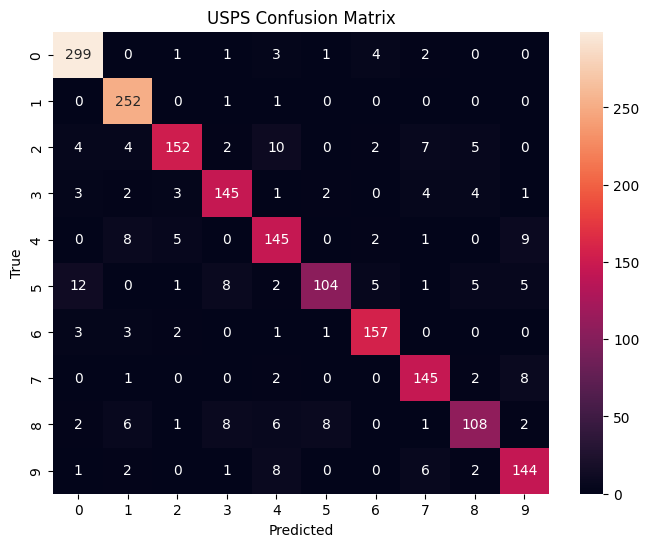


Classification report:
              precision    recall  f1-score   support

           0      0.923     0.961     0.942       311
           1      0.906     0.992     0.947       254
           2      0.921     0.817     0.866       186
           3      0.873     0.879     0.876       165
           4      0.810     0.853     0.831       170
           5      0.897     0.727     0.803       143
           6      0.924     0.940     0.932       167
           7      0.868     0.918     0.892       158
           8      0.857     0.761     0.806       142
           9      0.852     0.878     0.865       164

    accuracy                          0.888      1860
   macro avg      0.883     0.873     0.876      1860
weighted avg      0.888     0.888     0.886      1860



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("USPS Confusion Matrix")
plt.show()

print("\nClassification report:")
print(classification_report(y_test, predictions, digits=3))


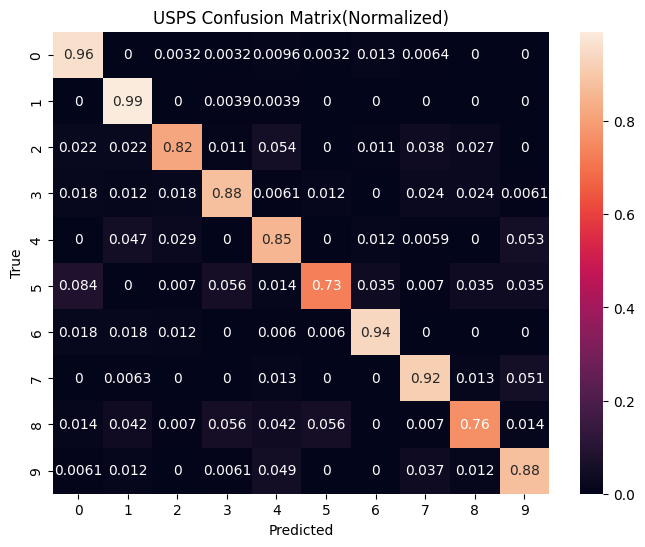

In [25]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("USPS Confusion Matrix(Normalized)")
plt.show()

In [26]:
def tolerant_accuracy(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred)<=1)

print("Tolerant accuracy:", tolerant_accuracy(y_test, predictions))


Tolerant accuracy: 0.9010752688172043


Number of misclassified samples: 209


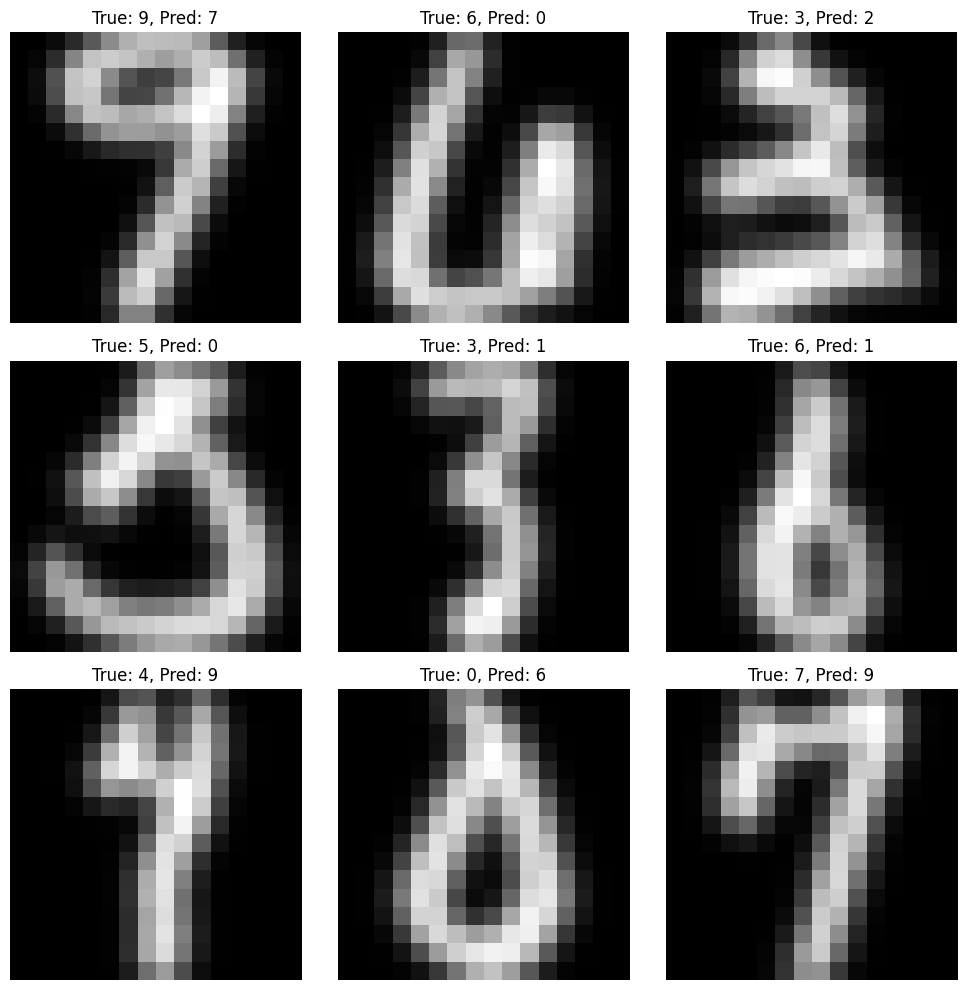

In [28]:
misclassified = np.where(predictions != y_test)[0]
print(f"Number of misclassified samples: {len(misclassified)}")

plt.figure(figsize=(10,10))

for i in range(9):
    idx = misclassified[i]
    
    image = X_test[idx].reshape(16, 16)

    plt.subplot(3, 3, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {y_test[idx]}, Pred: {predictions[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()
